# 🚀 Practice Day 25

**📅 Date:** 2026-10-05  
📁 Category: Phase 3 · SQL 고급(윈도우함수) (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice window functions in DuckDB — PARTITION BY, a moving average, LAG, and RANK — to analyze multiple branches over time
  (DuckDB 윈도우 함수 연습 — PARTITION BY, 이동평균, LAG, RANK로 여러 지점의 시계열 데이터 분석하기)
- Smooth out daily noise to see each branch's real trend, track day-over-day swings, and rank branches against each other on any given day
  (일별 노이즈를 걷어내고 지점별 실제 추세를 보고, 전일 대비 증감을 추적하고, 특정 날짜 기준 지점 순위를 매겨보기)

---
# 📂 Dataset

**Dataset Name:** Wellspring 약국 체인 — 지점별 일별 매출 / Wellspring Pharmacy Chain — Daily Revenue by Branch

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** 120 days of daily revenue (USD) across 5 New York branches (SoHo, Williamsburg, Chelsea, Astoria, Forest Hills) — 600 rows total (5 branches × 120 days), single table. Weekends run a bit higher, there's a mild upward trend across the period, and the data is clean — no missing values or duplicates. The focus is applying window functions per branch (PARTITION BY).
(5개 뉴욕 지점(SoHo/Williamsburg/Chelsea/Astoria/Forest Hills)의 120일간 일별 매출(USD) 데이터입니다(단일 테이블, 600행 = 5지점×120일). 주말에는 매출이 조금 더 높고, 기간 전체에 걸쳐 완만한 성장 추세가 있으며, 결측치·중복 없이 깨끗합니다. 지점(PARTITION) 단위로 윈도우 함수를 적용하는 데 초점을 둡니다.)

## Dataset Preview

In [32]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)
rng = np.random.default_rng(42)

# --- Generate daily revenue (USD) for a 5-branch pharmacy chain over 120 days ---
branches = ['SoHo', 'Williamsburg', 'Chelsea', 'Astoria', 'Forest Hills']
branch_base = {'SoHo': 16_000, 'Williamsburg': 12_000, 'Chelsea': 10_000,
               'Astoria': 8_500, 'Forest Hills': 7_250}

n_days = 120
dates = pd.date_range('2024-01-01', periods=n_days, freq='D')

rows = []
for branch in branches:
    base = branch_base[branch]
    for i, d in enumerate(dates):
        dow = d.dayofweek  # 0=Mon .. 6=Sun
        dow_factor = 1.15 if dow in (5, 6) else 1.0  # weekends a bit busier
        trend = 1 + 0.0015 * i  # mild growth over the period
        noise = rng.normal(1.0, 0.10)
        revenue = base * dow_factor * trend * noise
        revenue = int(round(revenue, -1))
        rows.append({'date': d, 'branch': branch, 'revenue': revenue})

df = pd.DataFrame(rows).sort_values(['branch', 'date']).reset_index(drop=True)

df.head(10)


,date,branch,revenue
0,2024-01-01,Astoria,8370
1,2024-01-02,Astoria,8840
2,2024-01-03,Astoria,9380
3,2024-01-04,Astoria,7630
4,2024-01-05,Astoria,8440
5,2024-01-06,Astoria,11310
6,2024-01-07,Astoria,9130
7,2024-01-08,Astoria,7880
8,2024-01-09,Astoria,8780
9,2024-01-10,Astoria,9340


## Dataset Information

In [33]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     600 non-null    datetime64[us]
 1   branch   600 non-null    str           
 2   revenue  600 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 14.2 KB

Shape: (600, 3)


,date,branch,revenue
count,600,600,600.000000
unique,NaN,5,NaN
top,NaN,Astoria,NaN
freq,NaN,120,NaN
mean,2024-02-29 12:00:00,NaN,12176.350000
min,2024-01-01 00:00:00,NaN,5280.000000
25%,2024-01-30 18:00:00,NaN,9177.500000
50%,2024-02-29 12:00:00,NaN,11235.000000
75%,2024-03-30 06:00:00,NaN,14742.500000
max,2024-04-29 00:00:00,NaN,25130.000000


---
# ❓ Business Questions

1. **(Analysis)** What is each branch's 7-day moving average revenue, and how does it smooth out the daily ups and downs?
   (지점별 7일 이동평균 매출은 어떻게 되며, 일별 변동을 어떻게 완화하는가?)
2. **(Analysis)** How much did each branch's revenue change from the previous day, and which days saw the biggest swings?
   (지점별 전일 대비 매출 증감은 얼마이며, 가장 큰 변동을 보인 날은 언제인가?)
3. **(Analysis)** On any given day, how do the 5 branches rank against each other by revenue, and does that ranking ever change day to day?
   (특정 날짜 기준으로 5개 지점의 매출 순위는 어떻게 되며, 그 순위가 날마다 바뀌는가?)
4. **(Visualization)** Show how each branch's smoothed (moving average) revenue trend moves over the 120 days.
   (지점별 이동평균 매출 추이는 120일간 어떻게 움직이는가?)
5. **(Visualization)** Compare total revenue across all 5 branches.
   (5개 지점의 총매출을 비교하면?)

---
# 🔍 Data Cleaning Check


In [34]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
date       0
branch     0
revenue    0
dtype: int64

Duplicate rows: 0

Dtypes
date       datetime64[us]
branch                str
revenue             int64
dtype: object

Column names
['date', 'branch', 'revenue']

Text columns — unique counts
branch    5
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is each branch's 7-day moving average revenue, and how does it smooth out the daily ups and downs? (지점별 7일 이동평균 매출은? 일별 변동을 어떻게 완화하는가?)

**Result:** On 2024-04-29 the 7-day average is SoHo **$19,583**, Williamsburg **$13,834**, Chelsea **$12,499**, Astoria **$10,810**, Forest Hills **$8,339**.
(2024-04-29 의 7일 이동평균은 SoHo $19,583, Williamsburg $13,834, Chelsea $12,499, Astoria $10,810, Forest Hills $8,339)

**Insight:** A single day can sit well above that average. On 2024-04-28 SoHo's revenue is **$25,130** and its 7-day average is **$19,466**, about **$5,664** higher.
(2024-04-28 SoHo 매출은 $25,130이고 7일 이동평균은 $19,466이라, 약 $5,664 높음)

In [35]:
# Question 1 (DuckDB, window function): 7-day moving average per branch

import duckdb

seven_day_ma = duckdb.sql("""
    SELECT 
        branch,
        date,
        revenue,
        AVG(revenue) OVER (
            PARTITION BY branch ORDER BY date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS ma7
    FROM df
    ORDER BY branch, date
""").df()

seven_day_ma

,branch,date,revenue,ma7
0,Astoria,2024-01-01,8370,8370.000000
1,Astoria,2024-01-02,8840,8605.000000
2,Astoria,2024-01-03,9380,8863.333333
3,Astoria,2024-01-04,7630,8555.000000
4,Astoria,2024-01-05,8440,8532.000000
...,...,...,...,...
595,Williamsburg,2024-04-25,13150,14114.285714
596,Williamsburg,2024-04-26,11060,13757.142857
597,Williamsburg,2024-04-27,15960,14077.142857
598,Williamsburg,2024-04-28,14520,13987.142857


## Question 2

**Question:** How much did each branch's revenue change from the previous day, and which days saw the biggest swings? (전일 대비 매출 증감은? 가장 큰 변동을 보인 날은?)

**Result:** The largest swing is SoHo on 2024-04-20, **+$6,970** (revenue **$22,370**). Next are SoHo on 2024-04-29, **-$6,730**, and Chelsea on 2024-04-15, **-$6,250**.
(가장 큰 변동은 2024-04-20 SoHo +$6,970, 매출 $22,370. 그다음은 2024-04-29 SoHo -$6,730, 2024-04-15 Chelsea -$6,250)

**Insight:** The biggest moves run both up and down. SoHo's two largest are a rise of **$6,970** and, nine days later, a drop of **$6,730**.
(가장 큰 변동은 증가와 감소가 함께 있음. SoHo의 두 건은 $6,970 상승과, 9일 뒤 $6,730 하락)

In [36]:
# Question 2 (DuckDB, window function): day-over-day change per branch using LAG
day_over_day_change = duckdb.sql("""
    SELECT *
    FROM (
        SELECT 
            branch,
            date,
            revenue,
            revenue - LAG(revenue) OVER (
                PARTITION BY branch ORDER BY date
            ) AS revenue_change
        FROM df
    )
    WHERE revenue_change IS NOT NULL
    ORDER BY ABS(revenue_change) DESC
""").df()

day_over_day_change

,branch,date,revenue,revenue_change
0,SoHo,2024-04-20,22370,6970
1,SoHo,2024-04-29,18400,-6730
2,Chelsea,2024-04-15,9190,-6250
3,Williamsburg,2024-03-25,10740,-5780
4,Williamsburg,2024-01-08,10680,-5280
...,...,...,...,...
590,Chelsea,2024-01-30,10440,-40
591,Forest Hills,2024-03-10,9810,-30
592,Chelsea,2024-04-26,12020,20
593,SoHo,2024-03-24,19900,-10


## Question 3

**Question:** On any given day, how do the 5 branches rank against each other by revenue, and does that ranking ever change day to day? (특정 날짜 기준 5개 지점의 매출 순위는? 날마다 바뀌는가?)

**Result:** The usual order is SoHo 1st (**116** of 120 days), Williamsburg 2nd (**103**), Chelsea 3rd (**88**), Astoria 4th (**85**), Forest Hills 5th (**102**). At least one rank changes on **79** of 119 day-to-day steps.
(보통의 순서는 SoHo 1위 116/120일, Williamsburg 2위 103일, Chelsea 3위 88일, Astoria 4위 85일, Forest Hills 5위 102일. 119번의 전일 대비 중 79번은 순위가 하나 이상 바뀜)

**Insight:** The order is stable at the ends and loose in the middle. SoHo is 2nd on only **4** days, and Williamsburg is 1st on those days. Chelsea ranges from 2nd to 5th.
(끝 순위는 고정되고 가운데는 움직임. SoHo가 2위인 날은 4일이고, 그 날 1위는 Williamsburg. Chelsea는 2위에서 5위까지 움직임)

In [37]:
# Question 3 (DuckDB, window function): daily rank of branches by revenue

duckdb.sql("""
    SELECT 
        branch,
        date,
        revenue,
        RANK() OVER (PARTITION BY date ORDER BY revenue DESC) AS daily_rank
    FROM df
    ORDER BY date, daily_rank
""").df()


,branch,date,revenue,daily_rank
0,SoHo,2024-01-01,16490,1
1,Williamsburg,2024-01-01,10770,2
2,Chelsea,2024-01-01,9120,3
3,Astoria,2024-01-01,8370,4
4,Forest Hills,2024-01-01,7410,5
...,...,...,...,...
595,SoHo,2024-04-29,18400,1
596,Williamsburg,2024-04-29,13390,2
597,Astoria,2024-04-29,12620,3
598,Chelsea,2024-04-29,11610,4


---
# 📈 Visualization

**Chart 1:** Line chart — 7-day moving average revenue trend by branch (선그래프: 지점별 7일 이동평균 매출 추이)

*Interpretation:* The five lines stay apart and rise. SoHo goes from about **$16,200** on 2024-01-07 to about **$19,600** on 2024-04-29. Forest Hills stays lowest, from about **$7,700** to about **$8,300**.
(다섯 선은 떨어진 채 오른쪽으로 올라감. SoHo는 2024-01-07 약 $16,200에서 2024-04-29 약 $19,600. Forest Hills는 가장 아래에 머물며 약 $7,700에서 약 $8,300)

---

**Chart 2:** Bar chart — total revenue by branch (막대그래프: 지점별 총매출)

*Interpretation:* SoHo **$2,167,520**, Williamsburg **$1,629,800**, Chelsea **$1,372,760**, Astoria **$1,156,700**, Forest Hills **$979,030**. SoHo is about **$1,188,490** above Forest Hills.
(SoHo $2,167,520, Williamsburg $1,629,800, Chelsea $1,372,760, Astoria $1,156,700, Forest Hills $979,030. SoHo가 Forest Hills보다 약 $1,188,490 높음)

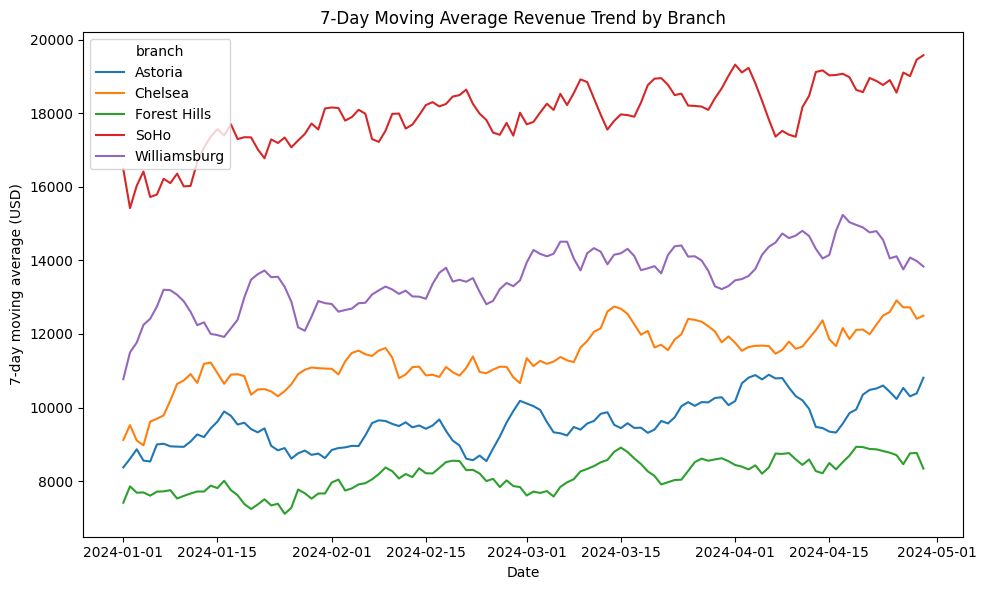

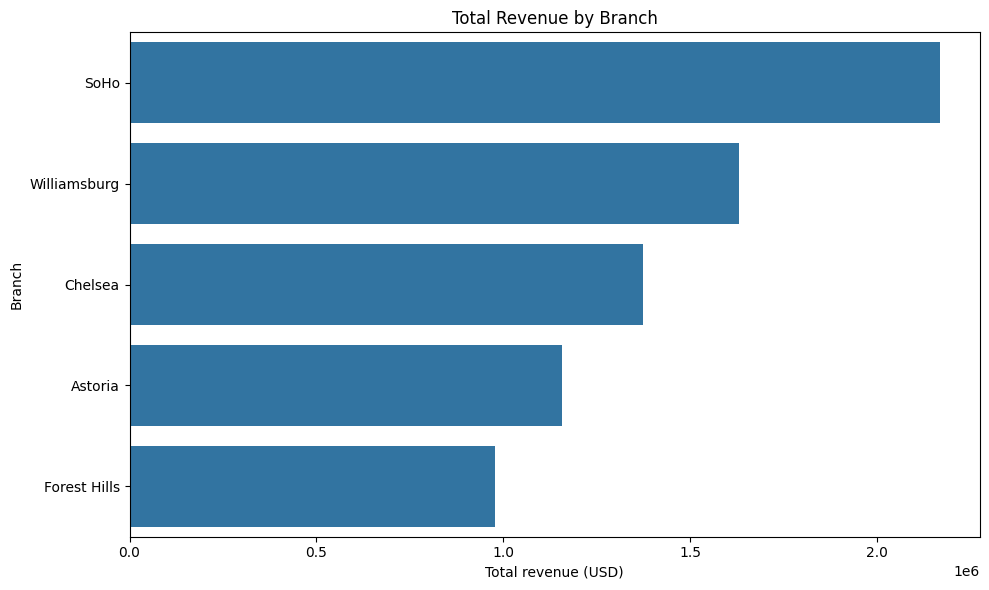

In [38]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: 7-day moving average trend, one line per branch (reuse the ma7 column from Question 1)
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='date', y='ma7', data=seven_day_ma, ax=ax, hue='branch')
ax.set_title('7-Day Moving Average Revenue Trend by Branch')
ax.set_xlabel('Date')
ax.set_ylabel('7-day moving average (USD)')
plt.tight_layout()
plt.show()

# Chart 2: total revenue by branch (bar)
total_revenue_by_branch = duckdb.sql("""
    SELECT 
        branch,
        SUM(revenue) AS total_revenue
    FROM df
    GROUP BY branch
    ORDER BY total_revenue DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='total_revenue', y='branch', data=total_revenue_by_branch, ax=ax)
ax.set_title('Total Revenue by Branch')
ax.set_xlabel('Total revenue (USD)')
ax.set_ylabel('Branch')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- On 2024-04-29 the 7-day average runs from SoHo **$19,583** down to Forest Hills **$8,339**. One SoHo day (2024-04-28) is **$25,130** against a **$19,466** average.
  (2024-04-29 7일 이동평균은 SoHo $19,583에서 Forest Hills $8,339까지. SoHo 2024-04-28 하루 매출 $25,130은 평균 $19,466과 갈림)
- The largest day-over-day move is SoHo on 2024-04-20, **+$6,970**. The next is SoHo on 2024-04-29, **-$6,730**.
  (전일 대비 가장 큰 변동은 2024-04-20 SoHo +$6,970. 그다음은 2024-04-29 SoHo -$6,730)
- SoHo is 1st on **116** of 120 days. A rank still changes on **79** of 119 day-to-day steps. Total revenue runs from SoHo **$2,167,520** to Forest Hills **$979,030**.
  (SoHo는 120일 중 116일 1위. 그래도 119번의 전일 대비 중 79번은 순위가 바뀜. 총매출은 SoHo $2,167,520에서 Forest Hills $979,030)

---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Compare branches on the 7-day average. On 2024-04-28 SoHo's day is **$5,664** above its average of **$19,466**.
   (지점 비교는 7일 이동평균으로 보기. 2024-04-28 SoHo는 평균 $19,466보다 $5,664 높음)
2. Review a day-over-day move as large as SoHo's **+$6,970** on 2024-04-20 and **-$6,730** on 2024-04-29.
   (2024-04-20 SoHo +$6,970, 2024-04-29 -$6,730처럼 큰 전일 대비 변동은 걸러 보기)
3. Treat SoHo as the usual leader (**116** of 120 days) and check the **4** days Williamsburg is 1st.
   (SoHo를 평소 1위로 두기. 120일 중 116일. Williamsburg가 1위인 4일은 따로 보기)

---
# ❌ Mistakes
*What mistakes did I make today?*

- I reached for `LAG` for the 7-day average. That average is `AVG` over the current row and the 6 rows before it.
  (7일 이동평균에 LAG를 쓰려 했음. 그 평균은 현재 행과 앞 6행의 AVG)
- I filtered `revenue_change` in the same `SELECT` as `LAG`. `WHERE` runs first, so DuckDB raised `WHERE clause cannot contain window functions!`
  (LAG와 같은 SELECT에서 revenue_change를 걸렀음. WHERE가 먼저 실행되어 WHERE clause cannot contain window functions! 가 남)
- The first line plot had no `hue`, so seaborn averaged the five branches and drew a 95% confidence band. Question 2 was also sorted by branch, then by the signed change, so the first row was not the largest swing.
  (첫 선그래프에 hue가 없어서 다섯 지점의 평균과 95% 신뢰구간이 나왔음. Question 2는 지점 다음 부호 있는 증감 순이라, 첫 행이 가장 큰 변동이 아니었음)

---
# ✅ What I Learned
*Today's biggest lesson*

- A 7-day average is `AVG() OVER (PARTITION BY branch ORDER BY date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)`.
  (7일 이동평균은 지점으로 나누고, 날짜 순으로 현재 행과 앞 6행을 평균내는 창)
- `LAG` returns the previous row. Its `NULL` on the first day has to be filtered in an outer query. The largest swing is `ORDER BY ABS(revenue_change) DESC`.
  (LAG는 전 행을 가져옴. 첫날의 NULL은 바깥 쿼리에서 거름. 가장 큰 변동은 절댓값 내림차순)
- Same-day rank is `RANK() OVER (PARTITION BY date ORDER BY revenue DESC)`. `sns.lineplot` needs `hue='branch'` or it averages every branch on that date.
  (같은 날 순위는 날짜로 나누고 매출 내림차순인 RANK. lineplot은 hue='branch'가 없으면 그 날 지점을 한데 평균냄)

---
# 🧠 Reflection

**What was difficult?**
`WHERE` on a window alias, and the shaded band on `sns.lineplot`.
(창 함수 별칭을 WHERE에 쓰는 것, 그리고 lineplot 주변의 띠)

**Why?**
`WHERE` runs before the window is calculated. Without `hue`, seaborn averages every `ma7` that shares a date and draws a 95% confidence interval.
(WHERE는 창 함수보다 먼저 실행됨. hue가 없으면 같은 날짜의 ma7을 평균 내고 95% 신뢰구간을 침)

**How did I solve it?**
Computed `LAG` inside a subquery and filtered outside it. Added `hue='branch'` so each branch is its own line.
(LAG는 안쪽 쿼리에서 계산하고 바깥에서 걸렀음. hue='branch'를 넣어 지점마다 선이 나오게 함)

**What would I do differently next time?**
Check whether the sort is by branch or by `ABS(revenue_change)` before reading the first row as the biggest swing.
(첫 행을 가장 큰 변동으로 읽기 전에, 정렬이 지점 기준인지 절댓값 기준인지 확인하기)


---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
`AVG` with a row frame, `LAG` in an outer filter, and `RANK` by date are clear.
(행 구간이 있는 AVG, 바깥 쿼리의 LAG, 날짜별 RANK는 이해함)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★★★☆☆☆
The window-versus-`WHERE` order and the line-plot band were the new parts.
(창 함수와 WHERE의 순서, 선그래프의 띠가 새로웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 26 — end-to-end mini pipeline  
  (엔드투엔드 미니 파이프라인)
 